Output()

ERROR:pymc.stats.convergence:There were 20 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


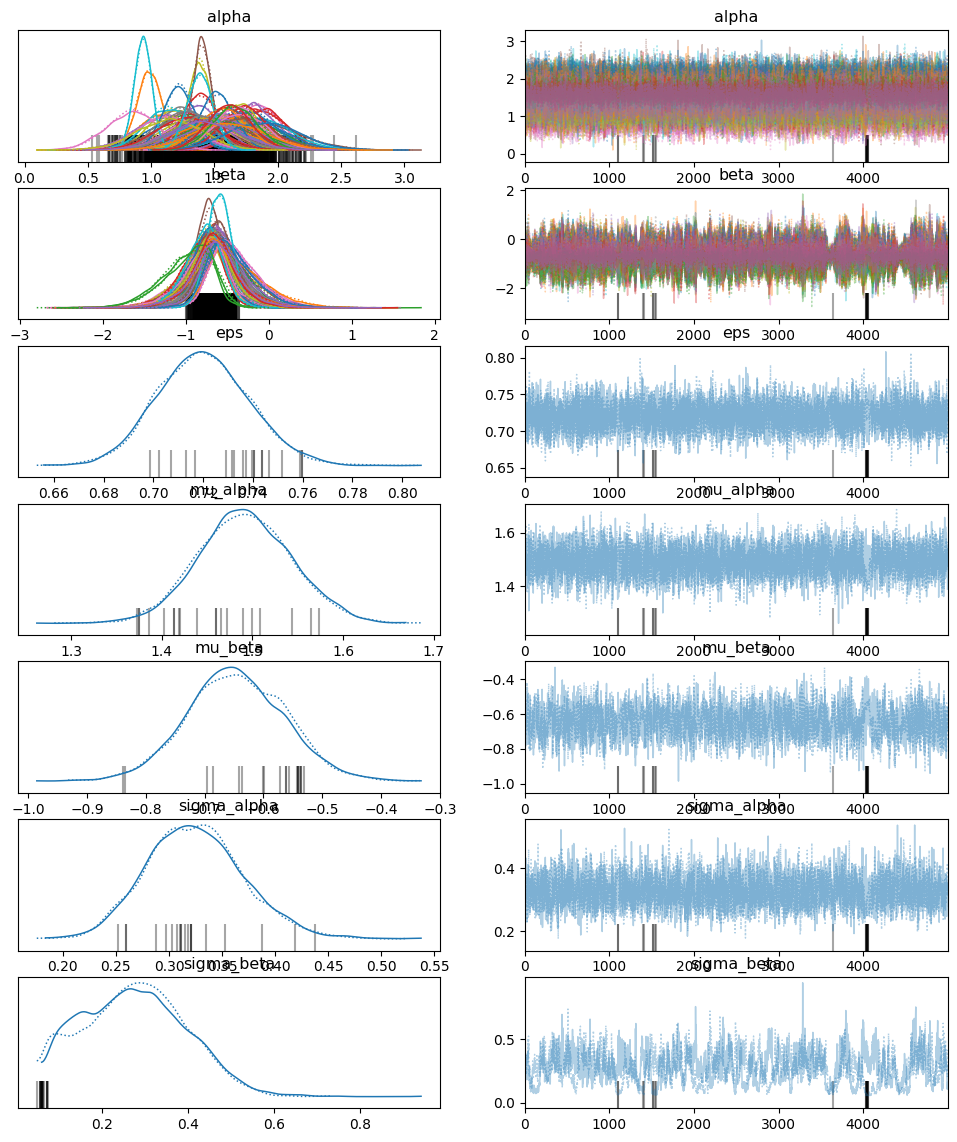

In [11]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az # Import arviz for plotting

def main():

    #load data
    data = pd.read_csv('radon.txt')

    county_names = data.county.unique()
    county_idx = data['county_code'].values

    with pm.Model() as hierarchical_model:

        # Hyperpriors
        mu_a = pm.Normal('mu_alpha', mu=0., sigma=100**2)
        sigma_a = pm.Uniform('sigma_alpha', lower=0, upper=100)
        mu_b = pm.Normal('mu_beta', mu=0., sigma=100**2)
        sigma_b = pm.Uniform('sigma_beta', lower=0, upper=100)

        # Intercept for each county, distributed around group mean mu_a
        a = pm.Normal('alpha', mu=mu_a, sigma=sigma_a, shape=len(data.county.unique()))
        # Slope for each county, distributed around group mean mu_b
        b = pm.Normal('beta', mu=mu_b, sigma=sigma_b, shape=len(data.county.unique()))

        # Model error
        eps = pm.Uniform('eps', lower=0, upper=100)

        # Expected value
        radon_est = a[county_idx] + b[county_idx] * data.floor.values

        # Data likelihood
        y_like = pm.Normal('y_like', mu=radon_est, sigma=eps, observed=data.log_radon)


    with hierarchical_model:
        # Increase target_accept to reduce divergences
        hierarchical_trace = pm.sample(5000, tune=2000, target_accept=0.9)

    # Use arviz.plot_trace instead of pm.traceplot
    az.plot_trace(hierarchical_trace)
    plt.show()

if __name__ == "__main__":
    main()